In [ ]:
!pip install upsetplot

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import re
from difflib import SequenceMatcher
from pathlib import Path
from matplotlib.ticker import MaxNLocator
from upsetplot import UpSet, from_indicators
import numpy as np


#drive.mount('/content/drive')
#os.listdir("/content/drive/MyDrive/estudos_snowbaling")
#base = "/content/drive/MyDrive/estudos_snowbaling"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE = Path(".")
CSV_BASE = BASE / "extended_tool_analisy" / "CSVs"

In [ ]:
TOOL_ALIASES = {
    "googleacademico": "googlescholar",
    "googlescholar": "googlescholar",
    "google scholar": "googlescholar",
    "lens": "lens",
    "litmaps": "litmaps",
    "litmap": "litmaps",
    "researchrabbit": "researchrabbit",
    "semanticscholar": "semanticscholar",
    "semantic scholar": "semanticscholar",
    "openalex": "openalex",
    "opencitations": "opencitations",
    "snowmap": "snowmap"
}

ALL_TOOLS = [
    "googlescholar",
    "lens",
    "litmaps",
    "researchrabbit",
    "semanticscholar",
    "openalex",
    "opencitations",
    "snowmap"
]

#normalization
def normalize_doi(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()

    if s in {"", "nan", "none", "null", "x"}:
        return None

    s = s.replace("https://doi.org/", "")
    s = s.replace("http://doi.org/", "")
    s = s.replace("https://dx.doi.org/", "")
    s = s.replace("http://dx.doi.org/", "")
    s = s.replace("doi.org/", "")
    s = s.replace("doi:", "")
    s = s.strip()

    # cerca un DOI anche dentro stringhe più lunghe
    m = re.search(r"10\.\S+", s)
    if not m:
        return None

    s = m.group(0)
    s = s.rstrip(" .;,)")
    return s or None

def normalize_title(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s or None

#finding columns
DOI_COL_CANDIDATES = [
    "doi", "DOI", "doi_norm", "document_doi", "paper_doi", "work_doi", "citing", "externalIds"
]

TITLE_COL_CANDIDATES = [
    "title", "Title", "paper_title", "document_title", "article_title",
    "display_name", "work_title", "titulo"
]


def find_doi_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in DOI_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "doi" in c.lower():
            return c

    return None


def find_title_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in TITLE_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "title" in c.lower() or "titulo" in c.lower():
            return c

    return None


#read each csv

def read_csv_with_fallback(csv_path: Path):
    for sep in [",", ";", "\t"]:
        try:
            return pd.read_csv(csv_path, sep=sep)
        except Exception:
            pass

    return pd.read_csv(csv_path)

def prepare_normalized_df(csv_path: Path, verbose=True):
    df = read_csv_with_fallback(csv_path)
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    doi_col = find_doi_column(df)
    title_col = find_title_column(df)

    #warning
    if verbose:
        if doi_col is None:
            print(f"[WARNING] {csv_path.name} → colonna DOI NON trovata")
        if title_col is None:
            print(f"[WARNING] {csv_path.name} → colonna TITLE NON trovata")

    if doi_col is not None:
        df["doi_norm"] = df[doi_col].apply(normalize_doi)
    else:
        df["doi_norm"] = None

    if title_col is not None:
        df["title_norm"] = df[title_col].apply(normalize_title)
    else:
        df["title_norm"] = None

    return df, doi_col, title_col

def extract_tool_from_filename(filename):
    stem = Path(filename).stem.lower()
    if "nossatool" in stem:
        return "nossatool"
    if "our_tool" in stem:
        return "our_tool"
    if "snowmap" in stem:
        return "snowmap"

    # General case: remove "artigoXX_" prefix
    parts = stem.split('_', 1)
    if len(parts) > 1 and parts[0].startswith("artigo"):
        return parts[1]

    # Fallback if no specific pattern matched
    return stem



### **FUNCTION FOR ANALYSIS OF MISSING DATA**

In [ ]:
MISSING_TOKENS = {
    "", "nan", "none", "null", "na", "n/a", "x", "-",
    "(missing journal)", "(missing abstract)", "(missing year)",
    "(missing doi)", "(missing abstract)"
}
MISSING_TOKENS = {t.lower() for t in MISSING_TOKENS}

SOURCE_COL_BY_TOOL = {
    "googlescholar": "Source",
    "lens": "Source Title",
    "litmaps": "Journal",
    "researchrabbit": "Journal",
    "openalex": "primary_location.source.display_name",
    "semanticscholar": "venue",
    "snowmap": "Venue",
    # "opencitations": None,
}

MISSING_COL_MAP = {
    "missing_doi_pct": "DOI",
    "missing_abstract_pct": "Abstract",
    "missing_venue_pct": "Venue",
    "missing_cited_by_pct": "Cited by",
    "missing_year_pct": "Year",
}

SLR_ORDER = ["SLR 1", "SLR 2", "SLR 3", "SLR 4"]


def is_missing_value(x):
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    return s in MISSING_TOKENS


def pct_missing(series: pd.Series) -> float:
    if series is None or len(series) == 0:
        return 0.0
    s = series.astype(str).str.strip().str.lower()
    return s.isin(MISSING_TOKENS).mean() * 100


def extract_tool_from_filename(filename):
    stem = Path(filename).stem.lower()

    if "nossatool" in stem:
        return "nossatool"
    if "our_tool" in stem:
        return "our_tool"
    if "snowmap" in stem:
        return "snowmap"

    parts = stem.split("_", 1)
    if len(parts) > 1 and parts[0].startswith("artigo"):
        return parts[1]

    return stem


def normalize_tool_name(tool_raw):
    return TOOL_ALIASES.get(str(tool_raw).lower().strip(), str(tool_raw).lower().strip())


def find_column_by_candidates(df, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None


def build_missing_summary_for_file(csv_path: Path, verbose=True):
    try:
        df = read_csv_with_fallback(csv_path).copy()
        df.columns = [c.strip() for c in df.columns]
    except Exception as e:
        return {
            "file": csv_path.name,
            "tool": normalize_tool_name(extract_tool_from_filename(csv_path.name)),
            "rows_total": 0,
            "missing_doi_pct": 0.0,
            "missing_abstract_pct": 0.0,
            "missing_venue_pct": 0.0,
            "missing_cited_by_pct": 0.0,
            "missing_year_pct": 0.0,
            "error": str(e),
        }

    tool = normalize_tool_name(extract_tool_from_filename(csv_path.name))

    doi_col = find_doi_column(df)
    title_col = find_title_column(df)

    abstract_col = find_column_by_candidates(df, [
        "abstract", "Abstract", "summary", "description"
    ])

    year_col = find_column_by_candidates(df, [
        "year", "Year", "publication_year", "publicationYear", "Publication Year", "creation"
    ])

    cited_by_col = find_column_by_candidates(df, [
        "Cited By", "Cited by", "cited_by_count", "citationCount", "cited_by", "Citing Works Count"
    ])

    venue_col = SOURCE_COL_BY_TOOL.get(tool)

    if verbose:
        print(f"\n[FILE] {csv_path.name}")
        print(f" tool={tool}")
        print(f" doi_col={doi_col}")
        print(f" abstract_col={abstract_col}")
        print(f" venue_col={venue_col if venue_col in df.columns else None}")
        print(f" cited_by_col={cited_by_col}")
        print(f" year_col={year_col}")

    out = {
        "file": csv_path.name,
        "tool": tool,
        "rows_total": len(df),
        "missing_doi_pct": pct_missing(df[doi_col]) if doi_col in df.columns else 100.0,
        "missing_abstract_pct": pct_missing(df[abstract_col]) if abstract_col in df.columns else 100.0,
        "missing_venue_pct": pct_missing(df[venue_col]) if venue_col in df.columns else 100.0,
        "missing_cited_by_pct": pct_missing(df[cited_by_col]) if cited_by_col in df.columns else 100.0,
        "missing_year_pct": pct_missing(df[year_col]) if year_col in df.columns else 100.0,
        "error": None,
    }

    return out


def analyze_missing_in_folder(folder_path: Path, verbose=True):
    csv_files = sorted(
        [
            p for p in folder_path.iterdir()
            if p.is_file()
            and p.suffix.lower() == ".csv"
            and "artigos_relevantes" not in p.stem.lower()
            and p.stem.lower() != "metadados_por_ferramenta"
            and p.stem.lower() != "matriz_metadados_por_ferramenta"
        ]
    )

    rows = []
    for csv_path in csv_files:
        rows.append(build_missing_summary_for_file(csv_path, verbose=verbose))

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values("tool").reset_index(drop=True)

    return df


def prepare_missing_plot_df(missing_summary_df, slr_name):
    df = missing_summary_df.copy()
    df["slr"] = slr_name
    return df


def combine_missing_summaries(*dfs):
    valid = [df.copy() for df in dfs if df is not None and not df.empty]
    if not valid:
        return pd.DataFrame()
    out = pd.concat(valid, ignore_index=True)
    out["slr"] = pd.Categorical(out["slr"], categories=SLR_ORDER, ordered=True)
    return out.sort_values(["slr", "tool"]).reset_index(drop=True)


def plot_missing_by_field_and_tool(missing_summary_df):
    if missing_summary_df.empty:
        print("Nessun dato da plottare.")
        return

    plot_df = (
        missing_summary_df
        .groupby("tool", as_index=True)[list(MISSING_COL_MAP.keys())]
        .mean()
        .T
    )

    plot_df.index = [MISSING_COL_MAP[idx] for idx in plot_df.index]

    fields = plot_df.index.tolist()
    tools = plot_df.columns.tolist()

    x = np.arange(len(fields))
    width = min(0.18, 0.9 / max(len(tools), 1))

    plt.figure(figsize=(14, 6))
    for i, tool in enumerate(tools):
        plt.bar(
            x + (i - (len(tools)-1)/2) * width,
            plot_df[tool].values,
            width,
            label=tool
        )

    plt.xticks(x, fields, rotation=30)
    plt.ylabel("Percentage of Missing Data (%)")
    plt.ylim(0, 100)
    plt.title(" ")
    plt.legend(title="Tool", bbox_to_anchor=(0.5, 1.15), loc="upper center", ncol=len(tools),
    frameon=False)
    plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    plt.tight_layout()
    plt.show()


### **ARTIGO 1**

In [ ]:
#folder1 = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr01")
folder1 = CSV_BASE / "new_csvs_slr01"

summary_df1, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder1)


artigo01_googleScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=5 | dup_title_rows=10
artigo01_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=2 | dup_title_rows=4
artigo01_litmaps.csv | dup_doi_groups=5 | dup_doi_rows=10 | dup_title_groups=4 | dup_title_rows=8
artigo01_openAlex.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=3 | dup_title_rows=6
[WARNING] artigo01_openCitations.csv → colonna TITLE NON trovata
artigo01_openCitations.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo01_researchRabbit.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=9 | dup_title_rows=19
artigo01_semanticScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=2 | dup_title_rows=15
artigo01_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=1 | dup_title_rows=2


In [ ]:
missing_df1 = analyze_missing_in_folder(folder1)
missing_df1 = prepare_missing_plot_df(missing_df1, "SLR 1")


[FILE] artigo01_googleScholar.csv
 tool=googlescholar
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source
 cited_by_col=None
 year_col=Year

[FILE] artigo01_lens.csv
 tool=lens
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source Title
 cited_by_col=Citing Works Count
 year_col=Publication Year

[FILE] artigo01_litmaps.csv
 tool=litmaps
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo01_openAlex.csv
 tool=openalex
 doi_col=doi
 abstract_col=abstract
 venue_col=primary_location.source.display_name
 cited_by_col=cited_by_count
 year_col=publication_year

[FILE] artigo01_openCitations.csv
 tool=opencitations
 doi_col=citing
 abstract_col=None
 venue_col=None
 cited_by_col=None
 year_col=creation

[FILE] artigo01_researchRabbit.csv
 tool=researchrabbit
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo01_semanticScholar.csv
 tool=semanticscholar
 doi_col=externalIds
 abst

### **ARTIGO 2**

In [ ]:
#folder2 = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr02")
folder2 = CSV_BASE / "new_csvs_slr02"

summary_df2, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder2)


artigo02_googleScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_litmaps.csv | dup_doi_groups=3 | dup_doi_rows=6 | dup_title_groups=3 | dup_title_rows=6
artigo02_openAlex.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
[WARNING] artigo02_openCitations.csv → colonna TITLE NON trovata
artigo02_openCitations.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_researchRabbit.csv | dup_doi_groups=4 | dup_doi_rows=8 | dup_title_groups=4 | dup_title_rows=8
artigo02_semanticScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0


In [ ]:
missing_df2 = analyze_missing_in_folder(folder2)
missing_df2 = prepare_missing_plot_df(missing_df2, "SLR 2")


[FILE] artigo02_googleScholar.csv
 tool=googlescholar
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source
 cited_by_col=None
 year_col=Year

[FILE] artigo02_lens.csv
 tool=lens
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source Title
 cited_by_col=Citing Works Count
 year_col=Publication Year

[FILE] artigo02_litmaps.csv
 tool=litmaps
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo02_openAlex.csv
 tool=openalex
 doi_col=doi
 abstract_col=abstract
 venue_col=primary_location.source.display_name
 cited_by_col=cited_by_count
 year_col=publication_year

[FILE] artigo02_openCitations.csv
 tool=opencitations
 doi_col=citing
 abstract_col=None
 venue_col=None
 cited_by_col=None
 year_col=creation

[FILE] artigo02_researchRabbit.csv
 tool=researchrabbit
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo02_semanticScholar.csv
 tool=semanticscholar
 doi_col=externalIds
 abst

### **ARTIGO 3**

In [ ]:
#folder3 = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr03")
folder3 = CSV_BASE / "new_csvs_slr03"

summary_df3, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder3)


artigo03_googleScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=6 | dup_title_rows=12
artigo03_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=5 | dup_title_rows=10
artigo03_litmaps.csv | dup_doi_groups=1 | dup_doi_rows=2 | dup_title_groups=1 | dup_title_rows=2
artigo03_openAlex.csv | dup_doi_groups=1 | dup_doi_rows=2 | dup_title_groups=5 | dup_title_rows=10
[WARNING] artigo03_openCitations.csv → colonna TITLE NON trovata
artigo03_openCitations.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo03_researchRabbit.csv | dup_doi_groups=14 | dup_doi_rows=31 | dup_title_groups=23 | dup_title_rows=49
artigo03_semanticScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=1 | dup_title_rows=2
artigo03_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0


In [ ]:
missing_df3 = analyze_missing_in_folder(folder3)
missing_df3 = prepare_missing_plot_df(missing_df3, "SLR 3")


[FILE] artigo03_googleScholar.csv
 tool=googlescholar
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source
 cited_by_col=None
 year_col=Year

[FILE] artigo03_lens.csv
 tool=lens
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source Title
 cited_by_col=Citing Works Count
 year_col=Publication Year

[FILE] artigo03_litmaps.csv
 tool=litmaps
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo03_openAlex.csv
 tool=openalex
 doi_col=doi
 abstract_col=abstract
 venue_col=primary_location.source.display_name
 cited_by_col=cited_by_count
 year_col=publication_year

[FILE] artigo03_openCitations.csv
 tool=opencitations
 doi_col=citing
 abstract_col=None
 venue_col=None
 cited_by_col=None
 year_col=creation

[FILE] artigo03_researchRabbit.csv
 tool=researchrabbit
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo03_semanticScholar.csv
 tool=semanticscholar
 doi_col=externalIds
 abst

### **ARTIGO 4**

In [ ]:
#folder4 = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr04")
folder4 = CSV_BASE / "new_csvs_slr04"

summary_df4, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder4)


artigo04_googleScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_litmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_openAlex.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
[WARNING] artigo04_openCitations.csv → colonna TITLE NON trovata
artigo04_openCitations.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_researchRabbit.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_semanticScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0


In [ ]:
missing_df4 = analyze_missing_in_folder(folder4)
missing_df4 = prepare_missing_plot_df(missing_df4, "SLR 4")


[FILE] artigo04_googleScholar.csv
 tool=googlescholar
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source
 cited_by_col=None
 year_col=Year

[FILE] artigo04_lens.csv
 tool=lens
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source Title
 cited_by_col=Citing Works Count
 year_col=Publication Year

[FILE] artigo04_litmap.csv
 tool=litmaps
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo04_openAlex.csv
 tool=openalex
 doi_col=doi
 abstract_col=abstract
 venue_col=primary_location.source.display_name
 cited_by_col=cited_by_count
 year_col=publication_year

[FILE] artigo04_openCitations.csv
 tool=opencitations
 doi_col=citing
 abstract_col=None
 venue_col=None
 cited_by_col=None
 year_col=creation

[FILE] artigo04_researchRabbit.csv
 tool=researchrabbit
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo04_semanticScholar.csv
 tool=semanticscholar
 doi_col=externalIds
 abstr

### **NUMBER OF ROWS FOR EACH TOOL FOR EACH SRL**


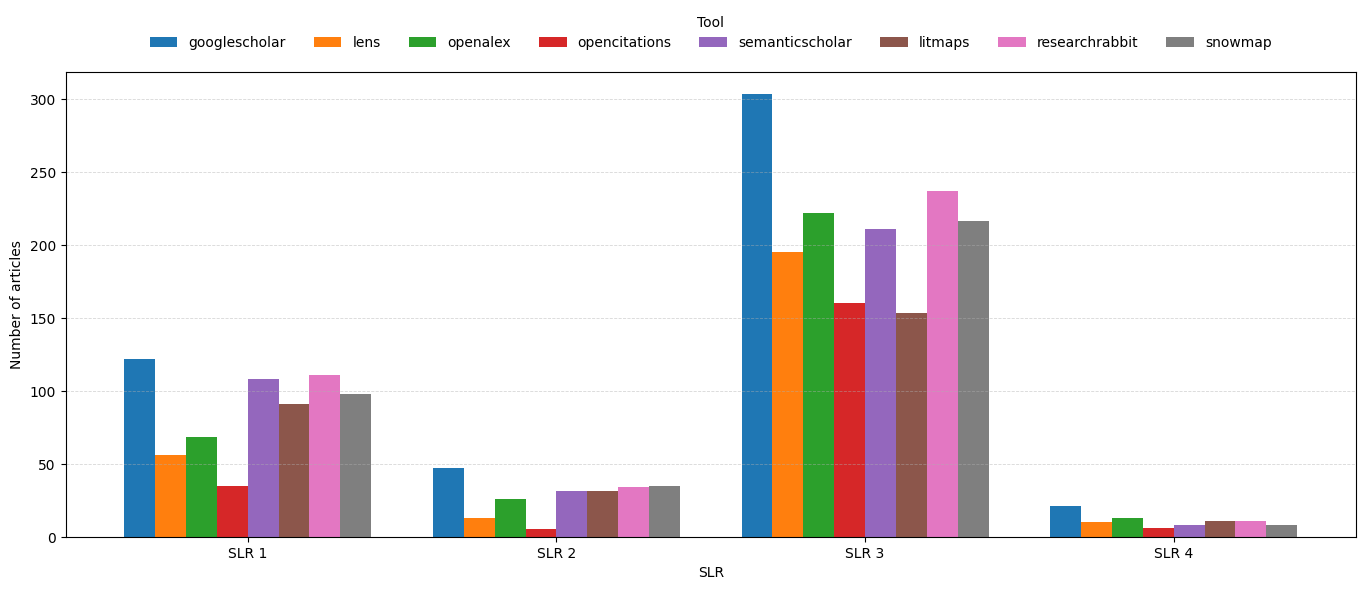

In [ ]:
plot_slr1 = prepare_plot_df(summary_df1, "SLR 1")
plot_slr2 = prepare_plot_df(summary_df2, "SLR 2")
plot_slr3 = prepare_plot_df(summary_df3, "SLR 3")
plot_slr4 = prepare_plot_df(summary_df4, "SLR 4")

plot_df = pd.concat([plot_slr1, plot_slr2, plot_slr3, plot_slr4], ignore_index=True)
plot_df
plot_articles_by_tool_and_slr(plot_df)


### **MISSING DATA ANALYSIS**

SUMMARY OF MISSING DATAS

In [ ]:
# unione
missing_all = combine_missing_summaries(
    missing_df1, missing_df2, missing_df3, missing_df4
)

display(missing_all)


,file,tool,rows_total,missing_doi_pct,missing_abstract_pct,missing_venue_pct,missing_cited_by_pct,missing_year_pct,error,slr
0,artigo01_googleScholar.csv,googlescholar,122,60.655738,4.098361,20.491803,100.000000,4.098361,None,SLR 1
1,artigo01_lens.csv,lens,56,0.000000,55.357143,3.571429,0.000000,0.000000,None,SLR 1
2,artigo01_litmaps.csv,litmaps,91,7.692308,10.989011,8.791209,0.000000,0.000000,None,SLR 1
3,artigo01_openAlex.csv,openalex,68,0.000000,61.764706,52.941176,0.000000,0.000000,None,SLR 1
4,artigo01_openCitations.csv,opencitations,35,0.000000,100.000000,100.000000,100.000000,0.000000,None,SLR 1
5,artigo01_researchRabbit.csv,researchrabbit,111,99.099099,15.315315,11.711712,0.000000,0.000000,None,SLR 1
6,artigo01_semanticScholar.csv,semanticscholar,108,0.000000,32.407407,21.296296,0.000000,13.888889,None,SLR 1
7,artigo01_snowmap.csv,snowmap,98,11.224490,11.224490,6.122449,23.469388,2.040816,None,SLR 1
8,artigo02_googleScholar.csv,googlescholar,47,70.212766,4.255319,17.021277,100.000000,4.255319,None,SLR 2
9,artigo02_lens.csv,lens,13,0.000000,30.769231,0.000000,0.000000,0.000000,None,SLR 2


PLOT OF MISSING DATA IN ARTICLE 1


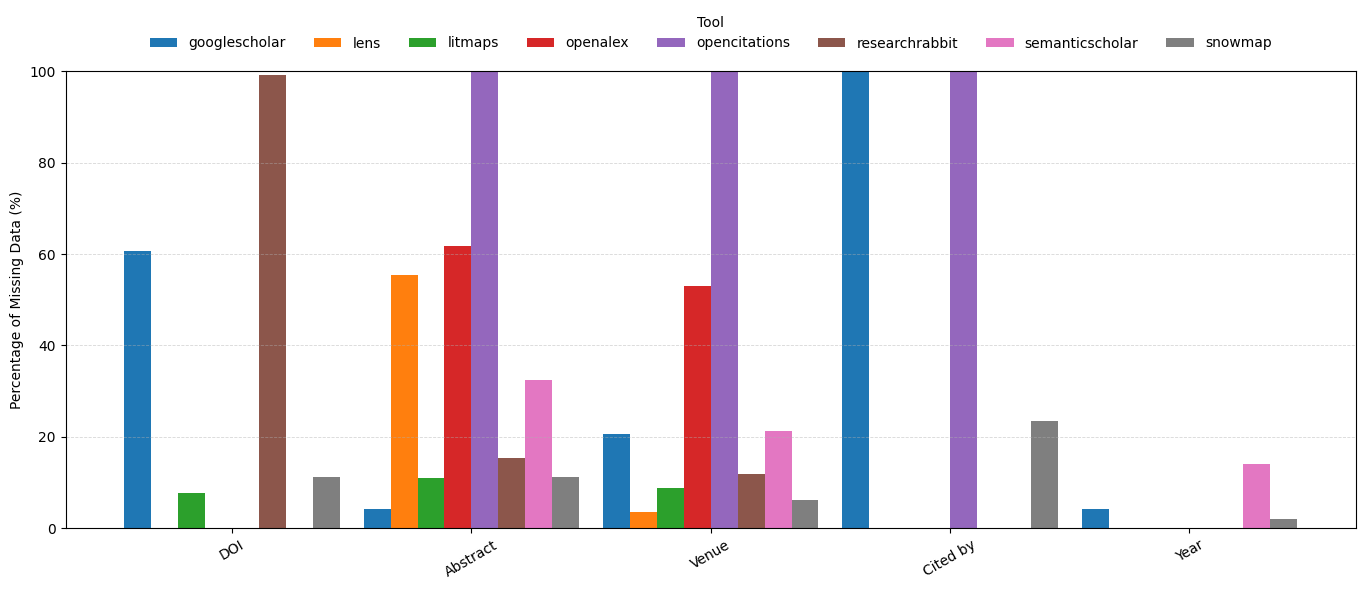

In [ ]:
plot_missing_by_field_and_tool(missing_df1)

PLOT OF MISSING DATA IN ARTICLE 2

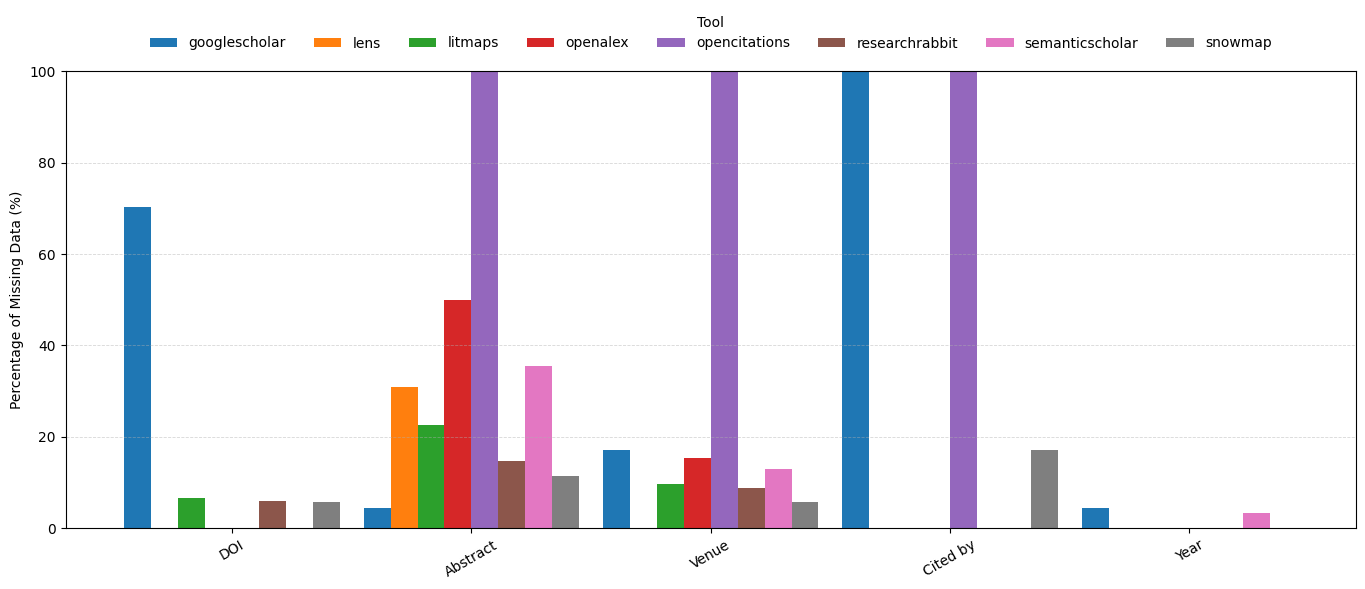

In [ ]:
plot_missing_by_field_and_tool(missing_df2)

PLOT OF MISSING DATA IN ARTICLE 3

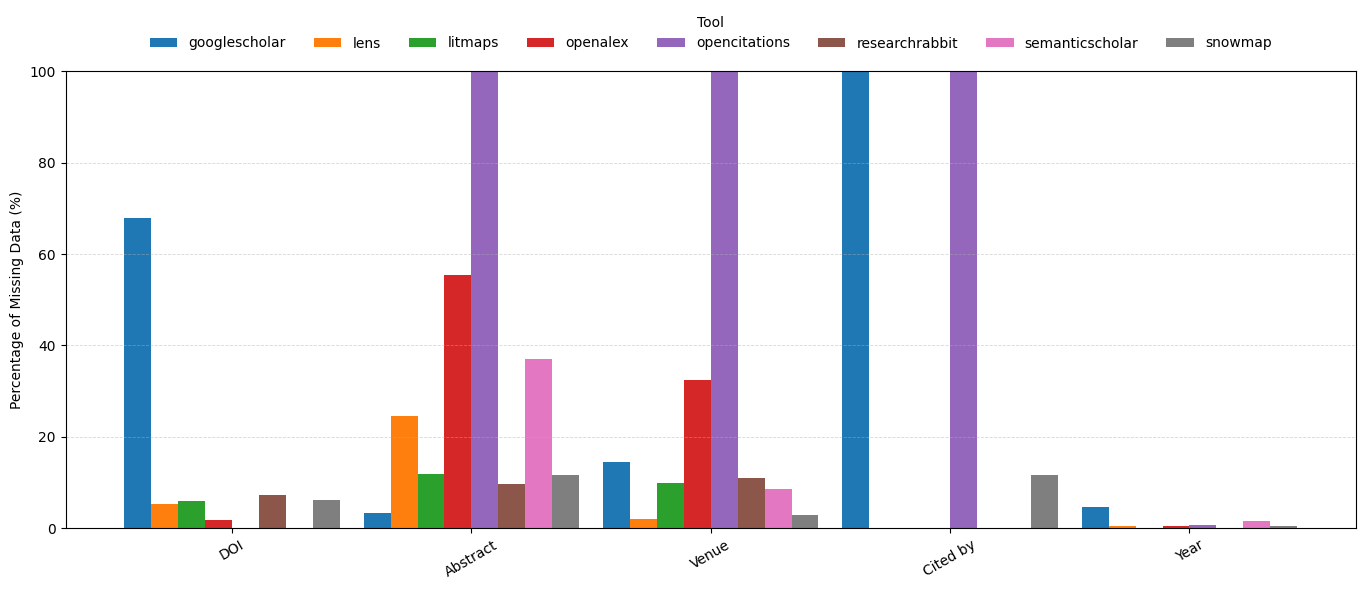

In [ ]:
plot_missing_by_field_and_tool(missing_df3)

PLOT OF MISSING DATA IN ARTICLE 4

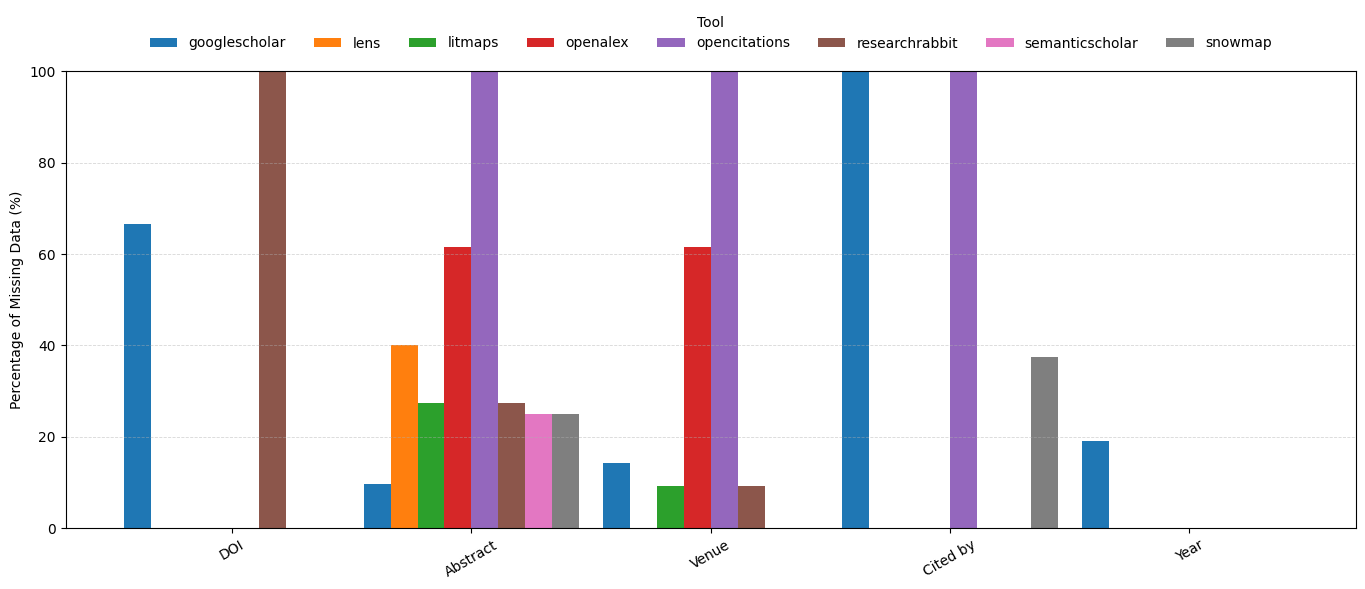

In [ ]:
plot_missing_by_field_and_tool(missing_df4)

In [ ]:
TOOL_ORDER = [
    "googlescholar",
    "lens",
    "openalex",
    "opencitations",
    "semanticscholar",
    "litmaps",
    "researchrabbit",
    "snowmap"
]

FIELD_ORDER = ["Abstract", "Cited by", "DOI", "Venue", "Year"]
palette = plt.get_cmap("tab10")
TOOL_COLORS = {tool: palette(i) for i, tool in enumerate(TOOL_ORDER)}
def plot_4_missing_charts(missing_dfs, titles):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)
    axes = axes.flatten()

    handles, labels = None, None
    field_order = ["Abstract", "Cited by", "DOI", "Venue", "Year"]

    for ax, df, title in zip(axes, missing_dfs, titles):
        pivot_df = df.pivot(index="field", columns="tool", values="missing_pct")

        pivot_df.index = [str(i).strip() for i in pivot_df.index]
        pivot_df = pivot_df.reindex(field_order).fillna(0)

        pivot_df.columns = [str(c).strip().lower() for c in pivot_df.columns]
        pivot_df = pivot_df.reindex(columns=TOOL_ORDER, fill_value=0)

        pivot_df.plot(
            kind="bar",
            ax=ax,
            color=[TOOL_COLORS[t] for t in TOOL_ORDER],
            width=0.82
        )

        ax.set_title(title, fontsize=14, fontweight="bold", pad=6)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(field_order, rotation=25, ha="right", fontsize=12, color="black")

        ax.tick_params(axis="y", labelsize=11, colors="black")
        ax.tick_params(axis="x", colors="black")

        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.grid(axis="x", visible=False)

        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    axes[0].set_ylabel("Percentage of Missing Data (%)", fontsize=12, color="black")
    axes[2].set_ylabel("Percentage of Missing Data (%)", fontsize=12, color="black")

    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=8,
        title="Tool",
        bbox_to_anchor=(0.5, 1.05),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

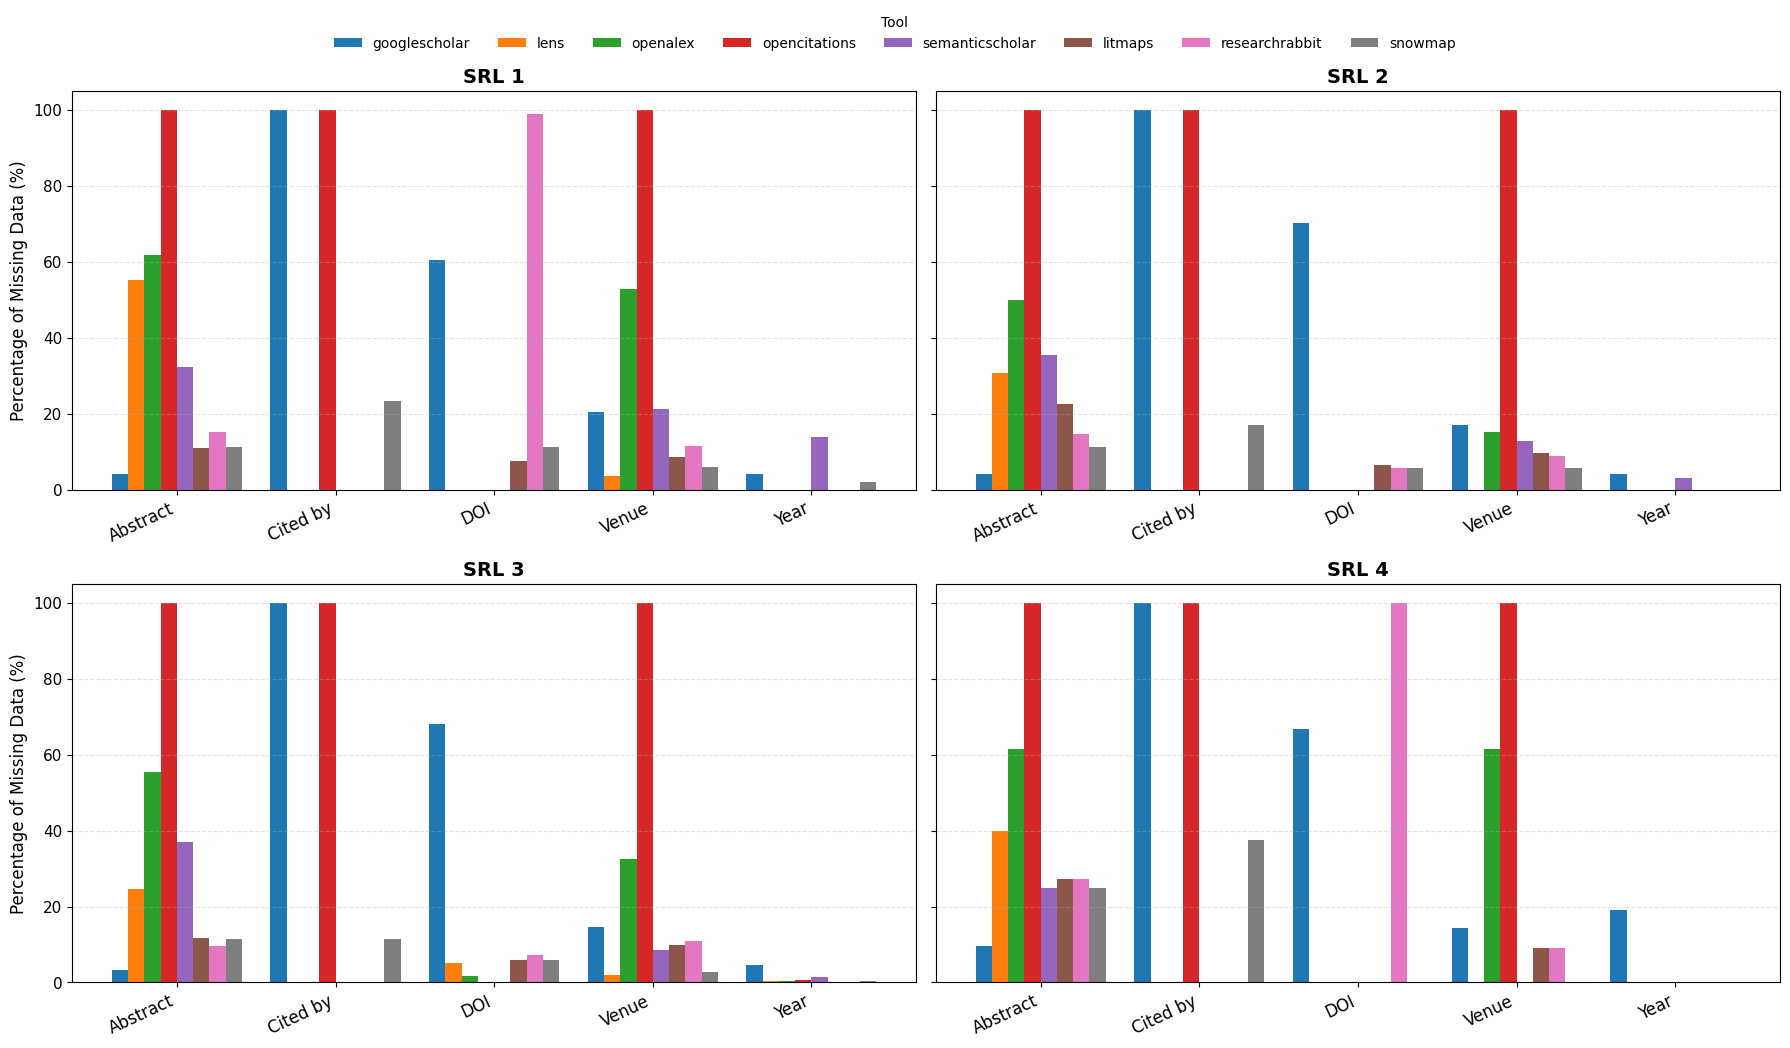

In [ ]:
#def function
def prepare_for_plotting_multiple_slr(missing_summary_df):
    if missing_summary_df.empty:
        return pd.DataFrame(columns=["tool", "field", "missing_pct"])

    melted_df = missing_summary_df.melt(
        id_vars=['tool'],
        value_vars=list(MISSING_COL_MAP.keys()),
        var_name='field_raw',
        value_name='missing_pct'
    )

    melted_df['field'] = melted_df['field_raw'].map(MISSING_COL_MAP)

    return melted_df[['tool', 'field', 'missing_pct']]

#preparing each df
prepared_missing_df1 = prepare_for_plotting_multiple_slr(missing_df1)
prepared_missing_df2 = prepare_for_plotting_multiple_slr(missing_df2)
prepared_missing_df3 = prepare_for_plotting_multiple_slr(missing_df3)
prepared_missing_df4 = prepare_for_plotting_multiple_slr(missing_df4)


plot_4_missing_charts(
    [prepared_missing_df1, prepared_missing_df2, prepared_missing_df3, prepared_missing_df4],
    ["SRL 1", "SRL 2", "SRL 3", "SRL 4"]
)